# Step 1 - Data splitting around an intervention

**Goal:** understand how `prepare_splits()` carves a daily time series into **train / test / holdout** windows around an intervention date.

We use the pre-built dummy dataset in `data/dummy_data.csv`. The series runs from **2018-01-01** to **2022-04-25** (1,576 days), with a simulated intervention on **2022-03-15** followed by a **42-day** post-intervention window. A +8 unit/day effect is baked into the post period so we can later check whether the pipeline recovers it.

In [1]:
%matplotlib inline

from IPython.display import display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from its2s.data_prep import prepare_splits

OUT_DIR = __import__("pathlib").Path.cwd() / "figures"
OUT_DIR.mkdir(exist_ok=True)

## 1a. Load the packaged dummy data

In [2]:
df = pd.read_csv("data/dummy_data.csv", parse_dates=["ds"])

print("=" * 60)
print("Dummy dataset")
print("=" * 60)
print(df.head())
print(f"\nShape : {df.shape}")
print(f"Date range: {df['ds'].min().date()} -> {df['ds'].max().date()}")
print(f"y  mean={df['y'].mean():.2f}  std={df['y'].std():.2f}  "
      f"min={df['y'].min():.2f}  max={df['y'].max():.2f}")

Dummy dataset
          ds          y  covar_linear  covar_dow  covar_noise
0 2018-01-01  50.609434      0.000588        0.0     0.418499
1 2018-01-02  48.095340      0.021211        1.0    -0.134027
2 2018-01-03  51.851468     -0.043014        2.0    -0.608240
3 2018-01-04  52.406850      0.008819        3.0    -0.776474
4 2018-01-05  46.798652      0.026332        4.0     2.671763

Shape : (1576, 5)
Date range: 2018-01-01 -> 2022-04-25
y  mean=53.17  std=7.81  min=36.34  max=76.45


## 1b. Calling prepare_splits

- `intervention_date` - the date the treatment happened.
- `test_days` - how many days *before* intervention become the held-out test window (we keep this at 365: there are ~4 years of pre-intervention data, plenty of room).
- `holdout_days` - how many days *after* intervention to track outcomes (42 here).

In [3]:
INTERVENTION = "2022-03-15"
TEST_DAYS    = 365
HOLDOUT_DAYS = 42

splits = prepare_splits(
    df,
    intervention_date=INTERVENTION,
    date_col="ds",
    test_days=TEST_DAYS,
    holdout_days=HOLDOUT_DAYS,
)

## 1c. Inspect the split sizes and date ranges

In [4]:
print("=" * 60)
print("Split sizes")
print("=" * 60)
for name, part in [
    ("train",        splits.train_df),
    ("test",         splits.test_df),
    ("holdout",      splits.holdout_df),
    ("full_predict", splits.full_predict_df),
]:
    if part.empty:
        rng = "empty"
    else:
        rng = f"{part['ds'].min().date()} -> {part['ds'].max().date()}"
    print(f"  {name:<15}  {len(part):>4} rows   {rng}")

Split sizes
  train            1227 rows   2018-01-01 -> 2021-05-11
  test              307 rows   2021-05-12 -> 2022-03-14
  holdout            42 rows   2022-03-15 -> 2022-04-25
  full_predict      349 rows   2021-05-12 -> 2022-04-25


## 1d. Understanding full_predict_df

`full_predict = test + holdout`. It is the window the model forecasts over. The model never sees this data during fitting - it is purely for evaluation.

In [5]:
expected = len(splits.test_df) + len(splits.holdout_df)
print(f"  len(test) + len(holdout) = {len(splits.test_df)} + {len(splits.holdout_df)} = {expected}")
print(f"  len(full_predict_df)     = {len(splits.full_predict_df)}")
assert len(splits.full_predict_df) == expected, "Mismatch - check for off-by-one"

  len(test) + len(holdout) = 307 + 42 = 349
  len(full_predict_df)     = 349


## 1e. Visualise the splits

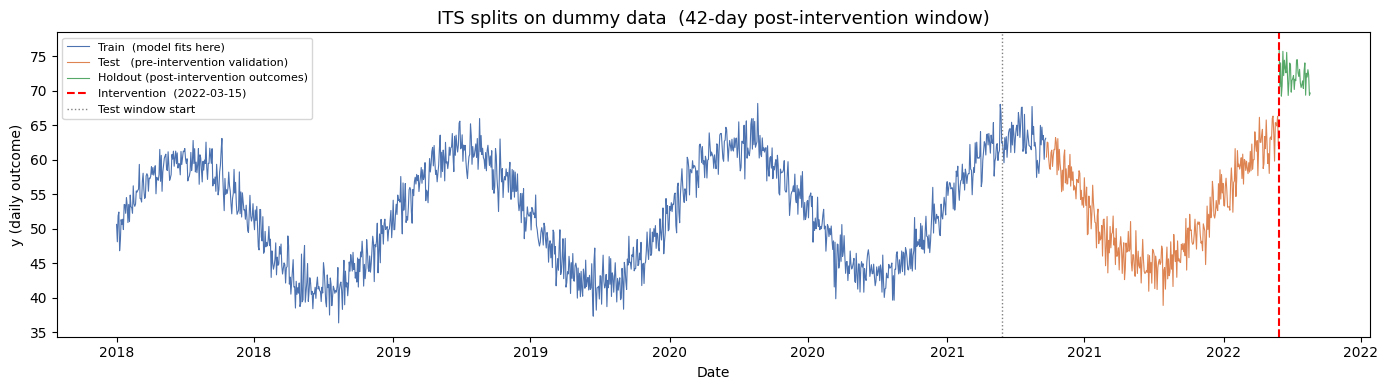

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

colors = {
    "train":   ("#4C72B0", "Train  (model fits here)"),
    "test":    ("#DD8452", "Test   (pre-intervention validation)"),
    "holdout": ("#55A868", "Holdout (post-intervention outcomes)"),
}

for split_name, (color, label) in colors.items():
    part = getattr(splits, f"{split_name}_df")
    ax.plot(part["ds"], part["y"], color=color, linewidth=0.8, label=label)

ax.axvline(splits.intervention_date, color="red", linestyle="--", linewidth=1.5,
           label=f"Intervention  ({INTERVENTION})")
ax.axvline(splits.intervention_date - pd.Timedelta(days=TEST_DAYS),
           color="gray", linestyle=":", linewidth=1, label="Test window start")

ax.set_title("ITS splits on dummy data  (42-day post-intervention window)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("y (daily outcome)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "step1_splits.png", dpi=150)
display(fig)
plt.close()

## Key takeaways

1. `prepare_splits` slices the DataFrame into three contiguous windows defined by the intervention date.
2. `train` ends `test_days` before intervention; `test` is the pre-intervention validation window; `holdout` is the post-intervention window.
3. `full_predict_df = test + holdout` - the set of dates the model is asked to forecast.
4. With only 42 post-intervention days, the holdout is short and the intervention effect must show up quickly to be detectable.

---

**Looking ahead.** The final `test_days` pre-intervention window becomes the held-out evaluation set for `run_single_its()`. If you also want to cross-validate (step 2) or tune hyperparameters (step 3) *without* touching that evaluation window, pass `cv_end_date = intervention_date - pd.Timedelta(days=test_days)` to `time_series_cv()` and `tune_model()`. Step 2 walks through this leakage issue in detail.
